In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("seaborn", sns.__version__)
print("ready ")

numpy 2.5.3
pandas 3.0.5
seaborn 0.13.2
ready 


In [2]:
# load the three raw World Bank CSVs
beds = pd.read_csv("../data/hospital_beds.csv", skiprows=4)
phys = pd.read_csv("../data/physicians.csv", skiprows=4)
life = pd.read_csv("../data/life_expectancy.csv", skiprows=4)

# quick peek at one of them
print("shape:", beds.shape)
beds.head()

shape: (265, 71)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,1.973383,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,0.170627,NaN,NaN,NaN,NaN,NaN,...,0.42,0.4,0.38,0.33,0.36,0.36,0.35,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,0.786552,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,2.061462,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# grab only the year columns
year_cols = [c for c in beds.columns if str(c).isdigit()]

# reshape wide → long (one row per country-year)
def to_long(df, indicator):
    long = df.melt(
        id_vars=["Country Name", "Country Code"],
        value_vars=year_cols,
        var_name="year",
        value_name=indicator,
    )
    return long.dropna(subset=[indicator])

# apply to all three files
beds_long = to_long(beds, "beds_per_1000")
phys_long = to_long(phys, "physicians_per_1000")
life_long = to_long(life, "life_expectancy")

# check row counts
print("beds rows:", len(beds_long))
print("phys rows:", len(phys_long))
print("life rows:", len(life_long))

beds_long.head()

beds rows: 5858
phys rows: 5529
life rows: 17126


,Country Name,Country Code,year,beds_per_1000
1,Africa Eastern and Southern,AFE,1960,1.973383
2,Afghanistan,AFG,1960,0.170627
3,Africa Western and Central,AFW,1960,0.786552
4,Angola,AGO,1960,2.061462
5,Albania,ALB,1960,5.102676


In [4]:
# world bank region/aggregate codes (not real countries)
regions = {
    "AFE","AFW","ARB","CEB","CSS","EAP","EAS","ECA","ECS","EMU",
    "EUU","FCS","HIC","HPC","IBD","IBT","IDA","IDB","IDX","INX",
    "LAC","LCN","LDC","LIC","LMC","LMY","LTE","MIC","MNA","NAC",
    "OED","OSS","PRE","PSS","PST","SSA","SSF","SST","TEA","TEC",
    "TLA","TMN","TSA","TSS","UMC","WLD",
}

def only_countries(df):
    return df[~df["Country Code"].isin(regions)].copy()

beds_long = only_countries(beds_long)
phys_long = only_countries(phys_long)
life_long = only_countries(life_long)

print("beds:", len(beds_long))
print("phys:", len(phys_long))
print("life:", len(life_long))

beds: 4801
phys: 5367
life: 14266


In [5]:
# connect to sqlite database
conn = sqlite3.connect("../data/nepal_health.db")

# save our 3 dataframes as tables
beds_long.to_sql("beds", conn, index=False, if_exists="replace")
phys_long.to_sql("physicians", conn, index=False, if_exists="replace")
life_long.to_sql("life_expectancy", conn, index=False, if_exists="replace")

# check tables
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)

,name
0,beds
1,physicians
2,life_expectancy


In [6]:
# look at 5 rows from the beds table
pd.read_sql("SELECT * FROM beds LIMIT 5", conn)

,Country Name,Country Code,year,beds_per_1000
0,Afghanistan,AFG,1960,0.170627
1,Angola,AGO,1960,2.061462
2,Albania,ALB,1960,5.102676
3,Argentina,ARG,1960,6.352251
4,Antigua and Barbuda,ATG,1960,7.706422


In [7]:
# nepal's hospital beds, sorted by year
query = """
SELECT year, beds_per_1000
FROM beds
WHERE "Country Code" = 'NPL'
ORDER BY year
"""
nepal_beds = pd.read_sql(query, conn)
nepal_beds.head(10)

,year,beds_per_1000
0,1960,0.115764
1,1970,0.135300
2,1975,0.137700
3,1980,0.175600
4,1985,0.180200
5,1987,0.227000
6,1988,0.239800
7,1989,0.244300
8,1990,0.243600
9,1991,0.237200


In [8]:
query = """
SELECT year, beds_per_1000
FROM beds
WHERE "Country Code" = 'NPL'
ORDER BY year DESC
"""
pd.read_sql(query, conn).head(10)

,year,beds_per_1000
0,2023,0.54
1,2022,0.53
2,2021,0.39
3,2020,0.28
4,2019,0.29
5,2018,0.29
6,2017,0.29
7,2016,0.28
8,2015,0.25
9,2014,0.27


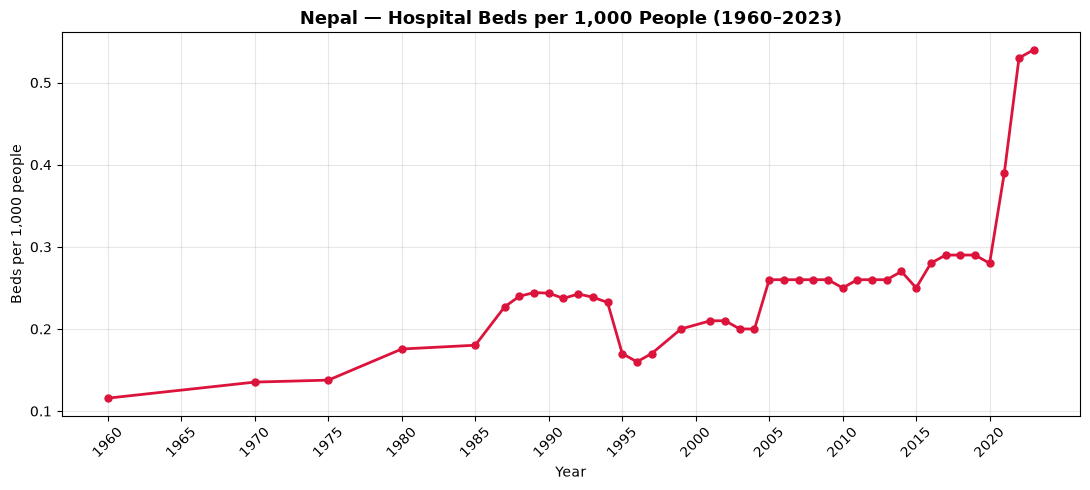

In [11]:
# pull nepal data
query = """
SELECT year, beds_per_1000
FROM beds
WHERE "Country Code" = 'NPL'
ORDER BY year
"""
nepal = pd.read_sql(query, conn)
nepal["year"] = nepal["year"].astype(int)

# chart
plt.figure(figsize=(11, 5))
plt.plot(nepal["year"], nepal["beds_per_1000"],
         marker="o", markersize=5, linewidth=2, color="crimson")
plt.title("Nepal — Hospital Beds per 1,000 People (1960–2023)", fontsize=13, weight="bold")
plt.xlabel("Year")
plt.ylabel("Beds per 1,000 people")
plt.xticks(range(1960, 2025, 5), rotation=45)
plt.grid(alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.savefig("../visuals/nepal_beds.png", dpi=150, bbox_inches="tight")
plt.show()

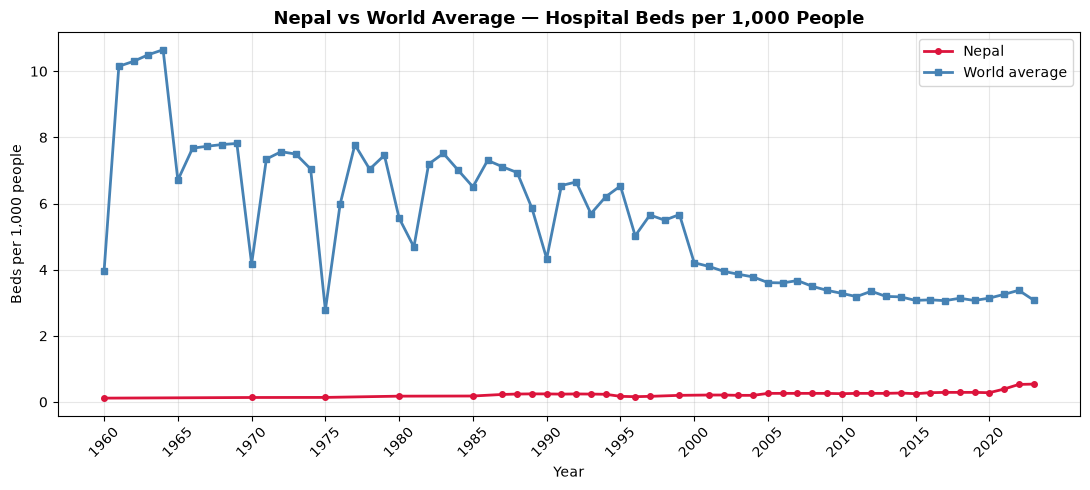

In [12]:
# nepal + world average per year
query = """
SELECT year,
       AVG(beds_per_1000) AS world_avg
FROM beds
GROUP BY year
ORDER BY year
"""
world = pd.read_sql(query, conn)
world["year"] = world["year"].astype(int)

# plot both
plt.figure(figsize=(11, 5))

plt.plot(nepal["year"], nepal["beds_per_1000"],
         marker="o", markersize=4, linewidth=2,
         color="crimson", label="Nepal")

plt.plot(world["year"], world["world_avg"],
         marker="s", markersize=4, linewidth=2,
         color="steelblue", label="World average")

plt.title("Nepal vs World Average — Hospital Beds per 1,000 People", 
          fontsize=13, weight="bold")
plt.xlabel("Year")
plt.ylabel("Beds per 1,000 people")
plt.xticks(range(1960, 2025, 5), rotation=45)
plt.grid(alpha=0.3)
plt.gca().set_axisbelow(True)
plt.legend()
plt.tight_layout()

plt.savefig("../visuals/nepal_vs_world.png", dpi=150, bbox_inches="tight")
plt.show()

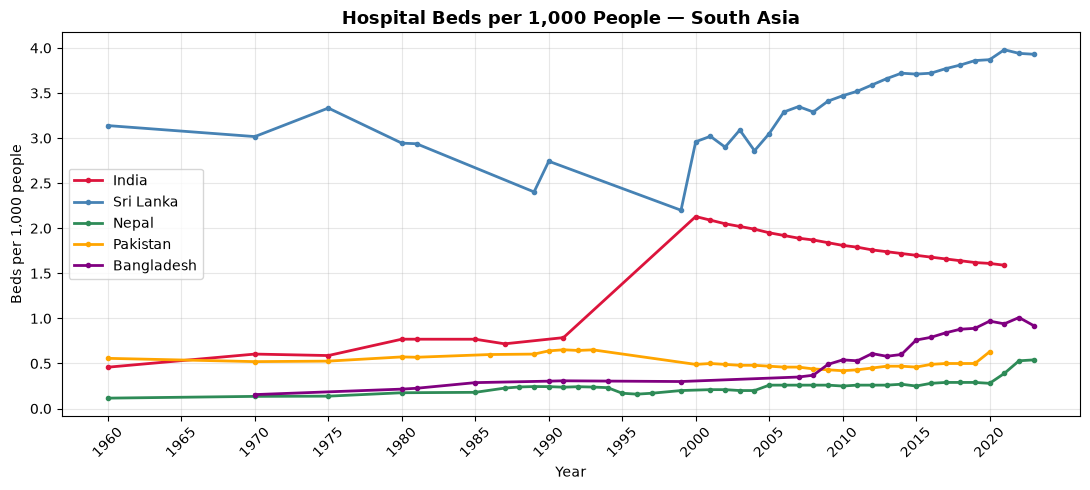

In [13]:
# south asian countries
query = """
SELECT year, "Country Name", beds_per_1000
FROM beds
WHERE "Country Code" IN ('NPL', 'IND', 'BGD', 'LKA', 'PAK')
ORDER BY year
"""
sa = pd.read_sql(query, conn)
sa["year"] = sa["year"].astype(int)

# plot one line per country
plt.figure(figsize=(11, 5))

countries = sa["Country Name"].unique()
colors = ["crimson", "steelblue", "seagreen", "orange", "purple"]

for country, color in zip(countries, colors):
    data = sa[sa["Country Name"] == country]
    plt.plot(data["year"], data["beds_per_1000"],
             marker="o", markersize=3, linewidth=2,
             color=color, label=country)

plt.title("Hospital Beds per 1,000 People — South Asia", 
          fontsize=13, weight="bold")
plt.xlabel("Year")
plt.ylabel("Beds per 1,000 people")
plt.xticks(range(1960, 2025, 5), rotation=45)
plt.grid(alpha=0.3)
plt.gca().set_axisbelow(True)
plt.legend()
plt.tight_layout()

plt.savefig("../visuals/south_asia_beds.png", dpi=150, bbox_inches="tight")
plt.show()

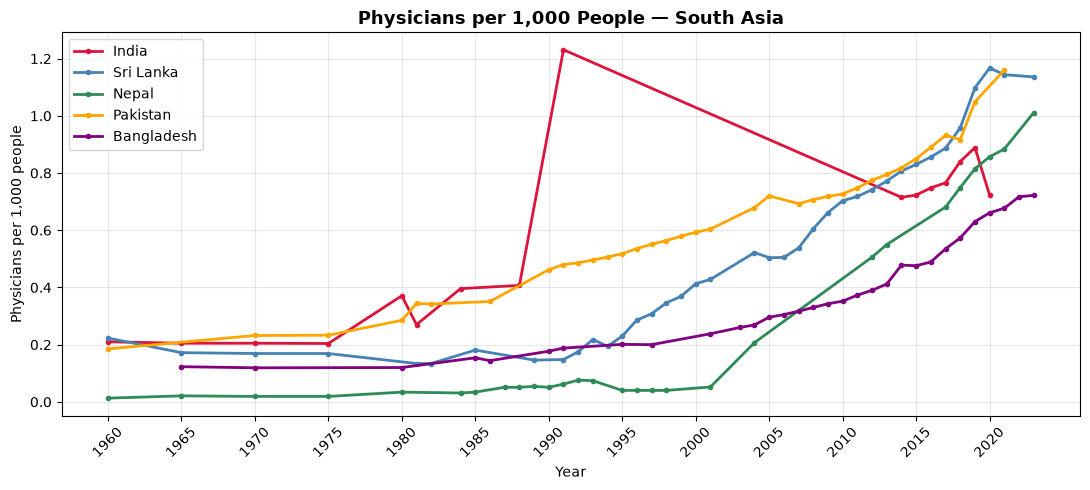

In [14]:
# physicians per 1000 — south asia
query = """
SELECT year, "Country Name", physicians_per_1000
FROM physicians
WHERE "Country Code" IN ('NPL', 'IND', 'BGD', 'LKA', 'PAK')
ORDER BY year
"""
sa_phys = pd.read_sql(query, conn)
sa_phys["year"] = sa_phys["year"].astype(int)

plt.figure(figsize=(11, 5))

countries = sa_phys["Country Name"].unique()
colors = ["crimson", "steelblue", "seagreen", "orange", "purple"]

for country, color in zip(countries, colors):
    data = sa_phys[sa_phys["Country Name"] == country]
    plt.plot(data["year"], data["physicians_per_1000"],
             marker="o", markersize=3, linewidth=2,
             color=color, label=country)

plt.title("Physicians per 1,000 People — South Asia", 
          fontsize=13, weight="bold")
plt.xlabel("Year")
plt.ylabel("Physicians per 1,000 people")
plt.xticks(range(1960, 2025, 5), rotation=45)
plt.grid(alpha=0.3)
plt.gca().set_axisbelow(True)
plt.legend()
plt.tight_layout()

plt.savefig("../visuals/south_asia_physicians.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# join beds + physicians on (country, year), keep recent years
query = """
SELECT b."Country Name",
       b.year,
       b.beds_per_1000,
       p.physicians_per_1000
FROM beds b
JOIN physicians p
  ON b."Country Code" = p."Country Code"
 AND b.year = p.year
WHERE b.year >= 2015
"""
df = pd.read_sql(query, conn)
print(df.shape)
df.head()

(856, 4)


,Country Name,year,beds_per_1000,physicians_per_1000
0,Afghanistan,2015,0.44,0.290
1,United Arab Emirates,2015,1.43,2.361
2,Argentina,2015,4.95,4.980
3,Armenia,2015,4.29,2.919
4,Australia,2015,3.79,3.486


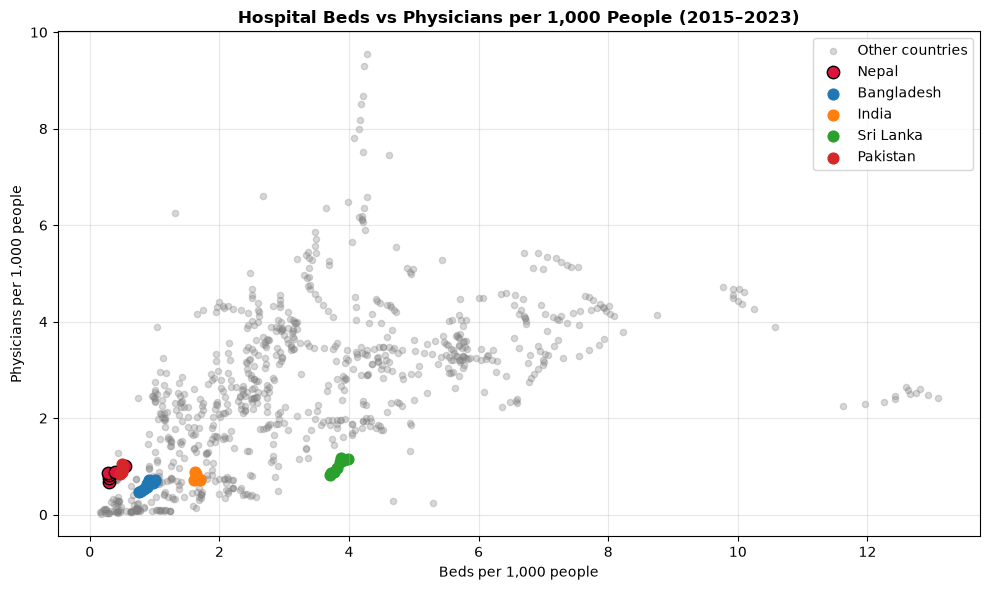

In [16]:
# scatter: beds vs physicians, colored by region of interest
plt.figure(figsize=(10, 6))

# all countries in grey
plt.scatter(df["beds_per_1000"], df["physicians_per_1000"],
            alpha=0.3, s=20, color="grey", label="Other countries")

# highlight nepal
nepal_pts = df[df["Country Name"] == "Nepal"]
plt.scatter(nepal_pts["beds_per_1000"], nepal_pts["physicians_per_1000"],
            s=80, color="crimson", edgecolor="black", label="Nepal")

# highlight south asia peers
peers = df[df["Country Name"].isin(["India", "Bangladesh", "Sri Lanka", "Pakistan"])]
for country in peers["Country Name"].unique():
    row = peers[peers["Country Name"] == country]
    plt.scatter(row["beds_per_1000"], row["physicians_per_1000"],
                s=60, label=country)

plt.title("Hospital Beds vs Physicians per 1,000 People (2015–2023)", 
          fontsize=12, weight="bold")
plt.xlabel("Beds per 1,000 people")
plt.ylabel("Physicians per 1,000 people")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("../visuals/beds_vs_physicians.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# join beds + life expectancy on country + year
query = """
SELECT b."Country Name",
       b.year,
       b.beds_per_1000,
       l.life_expectancy
FROM beds b
JOIN life_expectancy l
  ON b."Country Code" = l."Country Code"
 AND b.year = l.year
WHERE b.year >= 2015
"""
df2 = pd.read_sql(query, conn)
print(df2.shape)
df2.head()

(1159, 4)


,Country Name,year,beds_per_1000,life_expectancy
0,Afghanistan,2015,0.44,62.270000
1,Albania,2015,2.84,78.358000
2,United Arab Emirates,2015,1.43,82.076000
3,Argentina,2015,4.95,76.600000
4,Armenia,2015,4.29,74.870732


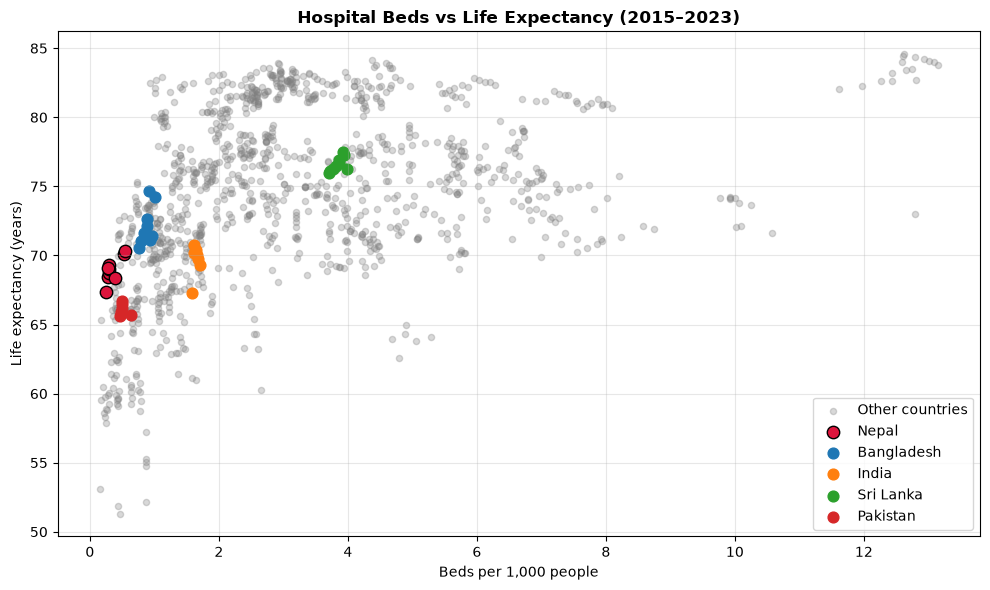

In [18]:
# scatter: beds vs life expectancy
plt.figure(figsize=(10, 6))

# all countries in grey
plt.scatter(df2["beds_per_1000"], df2["life_expectancy"],
            alpha=0.3, s=20, color="grey", label="Other countries")

# nepal highlighted
nepal_pts = df2[df2["Country Name"] == "Nepal"]
plt.scatter(nepal_pts["beds_per_1000"], nepal_pts["life_expectancy"],
            s=80, color="crimson", edgecolor="black", label="Nepal")

# south asia peers
peers = df2[df2["Country Name"].isin(["India", "Bangladesh", "Sri Lanka", "Pakistan"])]
for country in peers["Country Name"].unique():
    row = peers[peers["Country Name"] == country]
    plt.scatter(row["beds_per_1000"], row["life_expectancy"],
                s=60, label=country)

plt.title("Hospital Beds vs Life Expectancy (2015–2023)", 
          fontsize=12, weight="bold")
plt.xlabel("Beds per 1,000 people")
plt.ylabel("Life expectancy (years)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("../visuals/beds_vs_life.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# nepal 2023 stats
query = """
SELECT b."Country Name", b.year, b.beds_per_1000, l.life_expectancy
FROM beds b
JOIN life_expectancy l
  ON b."Country Code" = l."Country Code"
 AND b.year = l.year
WHERE b."Country Code" = 'NPL' AND b.year = 2023
"""
print("Nepal 2023:")
print(pd.read_sql(query, conn))
print()

# world average 2023
query = """
SELECT AVG(b.beds_per_1000) AS avg_beds,
       AVG(l.life_expectancy) AS avg_life
FROM beds b
JOIN life_expectancy l
  ON b."Country Code" = l."Country Code"
 AND b.year = l.year
WHERE b.year = 2023
"""
print("World avg 2023:")
print(pd.read_sql(query, conn))
print()

# south asia 2023
query = """
SELECT b."Country Name", b.beds_per_1000, l.life_expectancy
FROM beds b
JOIN life_expectancy l
  ON b."Country Code" = l."Country Code"
 AND b.year = l.year
WHERE b.year = 2023
  AND b."Country Code" IN ('NPL','IND','BGD','LKA','PAK')
ORDER BY b.beds_per_1000 DESC
"""
print("South Asia 2023:")
print(pd.read_sql(query, conn))

Nepal 2023:
  Country Name  year  beds_per_1000  life_expectancy
0        Nepal  2023           0.54           70.354

World avg 2023:
   avg_beds   avg_life
0  3.081233  75.216772

South Asia 2023:
  Country Name  beds_per_1000  life_expectancy
0    Sri Lanka           3.93           77.483
1   Bangladesh           0.92           74.672
2        Nepal           0.54           70.354


In [22]:
# south asia 2023 data
query = """
SELECT b."Country Name",
       b.beds_per_1000,
       l.life_expectancy
FROM beds b
JOIN life_expectancy l
  ON b."Country Code" = l."Country Code"
 AND b.year = l.year
WHERE b.year = 2023
  AND b."Country Code" IN ('NPL','IND','BGD','LKA','PAK')
ORDER BY b.beds_per_1000 DESC
"""
sa23 = pd.read_sql(query, conn)
print(sa23)

  Country Name  beds_per_1000  life_expectancy
0    Sri Lanka           3.93           77.483
1   Bangladesh           0.92           74.672
2        Nepal           0.54           70.354


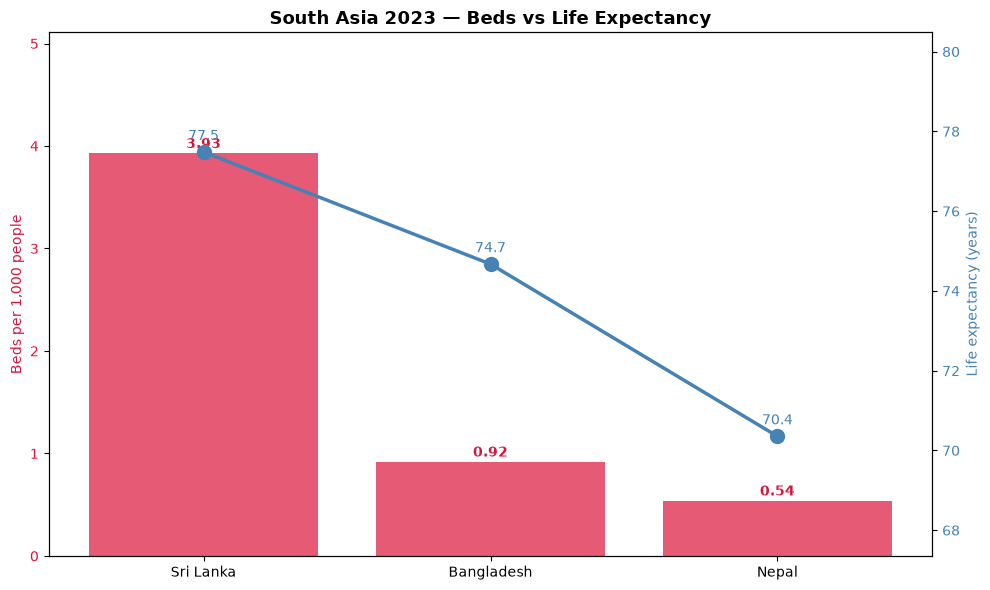

In [23]:
# south asia 2023 — dual axis bar + line
fig, ax1 = plt.subplots(figsize=(10, 6))

# bars: beds
bars = ax1.bar(sa23["Country Name"], sa23["beds_per_1000"],
               color="crimson", alpha=0.7)
ax1.set_ylabel("Beds per 1,000 people", color="crimson")
ax1.tick_params(axis="y", labelcolor="crimson")
ax1.set_ylim(0, sa23["beds_per_1000"].max() * 1.3)
    
# labels on bars
for bar, val in zip(bars, sa23["beds_per_1000"]):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f"{val:.2f}", ha="center", color="crimson", fontweight="bold")

# second axis: life expectancy
ax2 = ax1.twinx()
ax2.plot(sa23["Country Name"], sa23["life_expectancy"],
         marker="o", markersize=10, linewidth=2.5, color="steelblue")
ax2.set_ylabel("Life expectancy (years)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2.set_ylim(sa23["life_expectancy"].min() - 3, sa23["life_expectancy"].max() + 3)

# labels on points
for x, val in zip(sa23["Country Name"], sa23["life_expectancy"]):
    ax2.text(x, val + 0.3, f"{val:.1f}", ha="center", color="steelblue")

plt.title("South Asia 2023 — Beds vs Life Expectancy", 
          fontsize=13, weight="bold")
plt.tight_layout()

plt.savefig("../visuals/south_asia_2023.png", dpi=150, bbox_inches="tight")
plt.show()